In [12]:
# ============================================================
# RQ2a: Platform x Category Independence
# Run two datasets in parallel:
#   - Dataset A: 2022 IG vs YouTube (deduped by mode of category)
#   - Dataset B: 2024 IG vs TikTok (no dedup needed)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

DATA_PATH = "../../4 - ER unified/finalData_with_er.csv"
df = pd.read_csv(DATA_PATH)
# Plot style
plt.rcParams["font.sans-serif"] = ["Arial", "Helvetica", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
sns.set_style("whitegrid")

/var/folders/0g/pbpqnp6j47d2_qcp9yhz87ch0000gn/T/ipykernel_57068/3846460153.py:14: DtypeWarning: Columns (5,11,12,13,14,15,23,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


In [13]:
# ============================================================
# Step 1: Prepare two datasets
# ============================================================

# ---------- Dataset A: 2022 IG vs YouTube (dedup by mode) ----------
df_22_raw = df[
    (df["_year"] == 2022) &
    (df["_platform"].isin(["instagram", "youtube"])) &
    (df["category_unified"].notna()) &
    (~df["category_unified"].isin(["Other", "UNMAPPED"]))
].copy()


def mode_first(s):
    """
    Return the first mode of a series.
    If multiple modes (ties), returns the alphabetically first one.
    Returns np.nan if the series is empty.
    """
    m = s.mode()
    return m.iloc[0] if len(m) > 0 else np.nan


# Step 1a: Diagnose category consistency across months for each account
# i.e., how many (platform, handle) accounts have >1 unique category across months?
consistency = (
    df_22_raw.groupby(["_platform", "handle"])["category_unified"]
    .nunique()
    .reset_index(name="n_unique_categories")
)
inconsistent = consistency[consistency["n_unique_categories"] > 1]

print("=== 2022 category consistency check across months ===")
print(f"Total unique (platform, handle) pairs: {len(consistency):,}")
print(f"Accounts with >1 unique category across months: {len(inconsistent):,} "
      f"({len(inconsistent)/len(consistency)*100:.2f}%)")
print(f"\nDistribution of n_unique_categories per account:")
print(consistency["n_unique_categories"].value_counts().sort_index())

# Step 1b: Dedup by taking the mode of category per (platform, handle)
df_22 = (
    df_22_raw.groupby(["_platform", "handle"], as_index=False)
    .agg({
        "category_unified": mode_first,
        # Keep one country value per account (mode also)
        "_country": mode_first,
        # Keep followers as max (most recent / largest observed)
        "followers": "max",
    })
)

print(f"\n=== Dataset A: 2022 IG vs YouTube (after mode dedup) ===")
print(f"Rows before dedup: {len(df_22_raw):,}")
print(f"Rows after dedup:  {len(df_22):,}")
print(f"\nAccounts per platform:")
print(df_22["_platform"].value_counts())

# ---------- Dataset B: 2024 IG vs TikTok (no dedup needed) ----------
df_24 = df[
    (df["_year"] == 2024) &
    (df["_platform"].isin(["instagram", "tiktok"])) &
    (df["category_unified"].notna()) &
    (~df["category_unified"].isin(["Other", "UNMAPPED"]))
].copy()

print(f"\n=== Dataset B: 2024 IG vs TikTok ===")
print(f"Total rows: {len(df_24):,}")
print(f"\nAccounts per platform:")
print(df_24["_platform"].value_counts())

=== 2022 category consistency check across months ===
Total unique (platform, handle) pairs: 2,342
Accounts with >1 unique category across months: 188 (8.03%)

Distribution of n_unique_categories per account:
n_unique_categories
1    2154
2     187
3       1
Name: count, dtype: int64

=== Dataset A: 2022 IG vs YouTube (after mode dedup) ===
Rows before dedup: 7,903
Rows after dedup:  2,342

Accounts per platform:
_platform
instagram    1363
youtube       979
Name: count, dtype: int64

=== Dataset B: 2024 IG vs TikTok ===
Total rows: 7,601

Accounts per platform:
_platform
instagram    5282
tiktok       2319
Name: count, dtype: int64


In [14]:
# ============================================================
# Step 2: Core RQ2a analysis function
# Input: a filtered dataframe + a label
# Output: dict with contingency table, chi2, Cramer's V, residuals
# ============================================================

def run_rq2a_analysis(df_sub, title):
    """Run a complete RQ2a analysis on a filtered dataframe."""
    print(f"\n{'='*60}")
    print(f"RQ2a analysis: {title}")
    print(f"{'='*60}")
    
    # 1. Contingency table (observed frequencies)
    ct = pd.crosstab(df_sub["_platform"], df_sub["category_unified"])
    print(f"\n--- Contingency table (observed) ---")
    print(ct)
    
    # 2. Row-proportions (for stacked bar chart)
    ct_prop = ct.div(ct.sum(axis=1), axis=0)
    print(f"\n--- Row-proportions (%) ---")
    print((ct_prop * 100).round(2))
    
    # 3. Chi-square test of independence
    chi2, p, dof, expected = chi2_contingency(ct)
    n = ct.values.sum()
    
    # 4. Cramer's V (effect size, sample-size invariant)
    # V = sqrt(chi2 / (n * min(r-1, c-1)))
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    
    print(f"\n--- Test results ---")
    print(f"chi2 = {chi2:.2f}")
    print(f"df   = {dof}")
    print(f"p    = {p:.2e}")
    print(f"n    = {n:,}")
    print(f"Cramer's V = {cramers_v:.4f}")
    
    # Cohen's convention for Cramer's V (depends on df* = min(r-1, c-1))
    df_star = min(ct.shape) - 1
    if df_star == 1:
        thresholds = (0.10, 0.30, 0.50)
    elif df_star == 2:
        thresholds = (0.07, 0.21, 0.35)
    else:
        thresholds = (0.06, 0.17, 0.29)
    
    if cramers_v < thresholds[0]:
        strength = "negligible"
    elif cramers_v < thresholds[1]:
        strength = "weak"
    elif cramers_v < thresholds[2]:
        strength = "moderate"
    else:
        strength = "strong"
    print(f"Effect size (df*={df_star}): {strength}")
    
    # 5. Expected frequency validity check (>= 5 for chi-square approximation)
    expected_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns)
    print(f"\n--- Expected frequency validity check ---")
    print(f"Min expected frequency: {expected.min():.2f}")
    pct_low = (expected < 5).sum() / expected.size * 100
    print(f"Cells with expected < 5: {(expected < 5).sum()} / {expected.size} ({pct_low:.1f}%)")
    if pct_low > 20:
        print("WARNING: >20% cells with expected < 5, chi-square approximation may be unreliable")
    else:
        print("OK: expected frequency check passed")
    
    # 6. Standardized residuals (Pearson)
    # r = (observed - expected) / sqrt(expected)
    std_residuals = (ct - expected_df) / np.sqrt(expected_df)
    print(f"\n--- Standardized residuals ---")
    print(std_residuals.round(2))
    print("(|r| > 2 indicates significant deviation from independence)")
    
    return {
        "ct": ct,
        "ct_prop": ct_prop,
        "chi2": chi2,
        "p": p,
        "dof": dof,
        "n": n,
        "cramers_v": cramers_v,
        "strength": strength,
        "expected": expected_df,
        "std_residuals": std_residuals,
    }


# Run both datasets
res_22 = run_rq2a_analysis(df_22, "2022 IG vs YouTube (mode-deduped)")
res_24 = run_rq2a_analysis(df_24, "2024 IG vs TikTok")


RQ2a analysis: 2022 IG vs YouTube (mode-deduped)

--- Contingency table (observed) ---
category_unified  Beauty&Fashion  Entertainment  Knowledge&Info  Lifestyle  \
_platform                                                                    
instagram                    112            386              28        295   
youtube                       10            282             112        132   

category_unified  Music  Sports  Tech&Gaming  
_platform                                     
instagram           331     194           17  
youtube             324      15          104  

--- Row-proportions (%) ---
category_unified  Beauty&Fashion  Entertainment  Knowledge&Info  Lifestyle  \
_platform                                                                    
instagram                   8.22          28.32            2.05      21.64   
youtube                     1.02          28.80           11.44      13.48   

category_unified  Music  Sports  Tech&Gaming  
_platform             

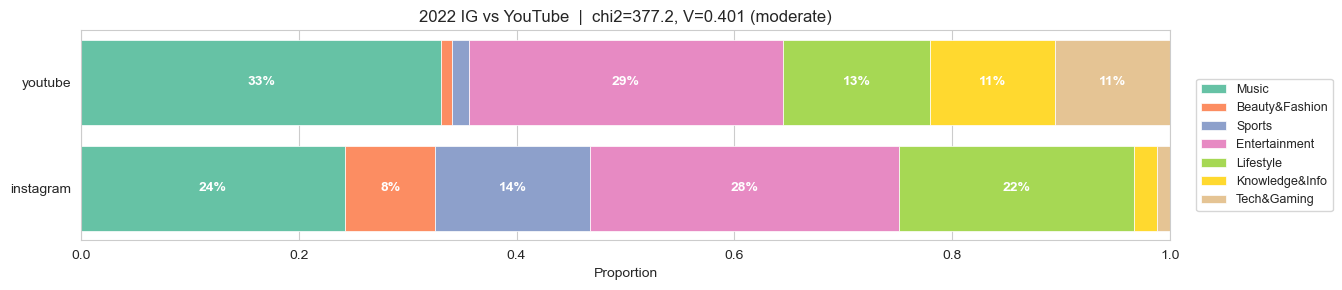

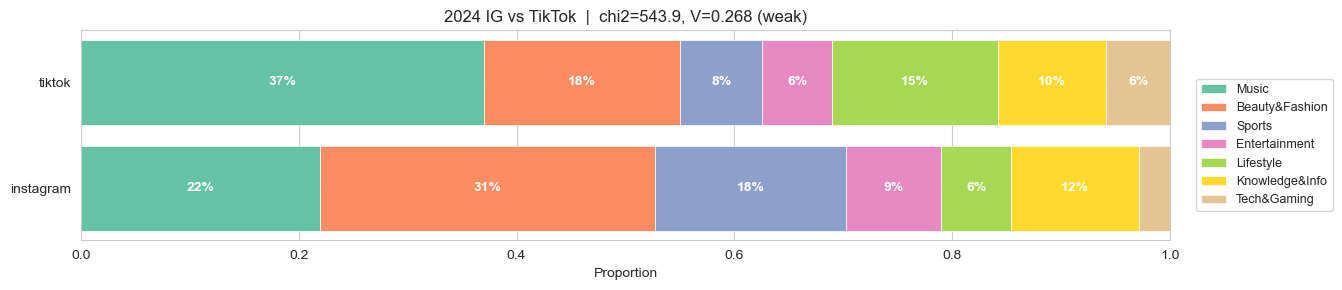

In [15]:
# ============================================================
# Step 3: Visualization 1 - Stacked bar chart of category share
# ============================================================

# Use a unified category order across both datasets (sorted by total frequency)
all_cats = sorted(
    set(res_22["ct"].columns) | set(res_24["ct"].columns),
    key=lambda c: -(
        res_22["ct"].get(c, pd.Series(0)).sum() +
        res_24["ct"].get(c, pd.Series(0)).sum()
    ),
)

# Color palette (colorblind-friendly)
colors = sns.color_palette("Set2", n_colors=len(all_cats))
cat_color_map = dict(zip(all_cats, colors))


def plot_stacked(ax, res, title):
    """Plot a stacked horizontal bar chart for one analysis result."""
    ct_prop = res["ct_prop"]
    left = np.zeros(len(ct_prop))
    for cat in all_cats:
        if cat in ct_prop.columns:
            vals = ct_prop[cat].values
            ax.barh(
                ct_prop.index, vals, left=left,
                color=cat_color_map[cat], label=cat,
                edgecolor="white", linewidth=0.5
            )
            for j, v in enumerate(vals):
                if v > 0.05:
                    ax.text(
                        left[j] + v / 2, j, f"{v*100:.0f}%",
                        ha="center", va="center", fontsize=10,
                        color="white", fontweight="bold"
                    )
            left += vals
    ax.set_xlim(0, 1)
    ax.set_title(title)
    ax.set_xlabel("Proportion")


# --- Figure 1: 2022 IG vs YouTube ---
fig1, ax1 = plt.subplots(figsize=(12, 3))
plot_stacked(
    ax1, res_22,
    f"2022 IG vs YouTube  |  chi2={res_22['chi2']:.1f}, V={res_22['cramers_v']:.3f} ({res_22['strength']})"
)
handles, labels = ax1.get_legend_handles_labels()
fig1.legend(handles, labels, loc="center right", bbox_to_anchor=(1.12, 0.5), fontsize=9)
plt.tight_layout()
plt.savefig("rq2a_stacked_bars_2022.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Figure 2: 2024 IG vs TikTok ---
fig2, ax2 = plt.subplots(figsize=(12, 3))
plot_stacked(
    ax2, res_24,
    f"2024 IG vs TikTok  |  chi2={res_24['chi2']:.1f}, V={res_24['cramers_v']:.3f} ({res_24['strength']})"
)
handles, labels = ax2.get_legend_handles_labels()
fig2.legend(handles, labels, loc="center right", bbox_to_anchor=(1.12, 0.5), fontsize=9)
plt.tight_layout()
plt.savefig("rq2a_stacked_bars_2024.png", dpi=150, bbox_inches="tight")
plt.show()


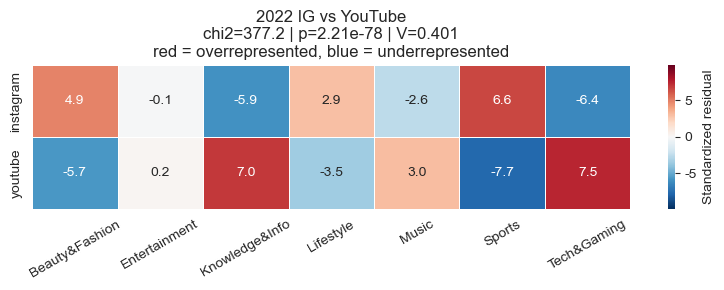

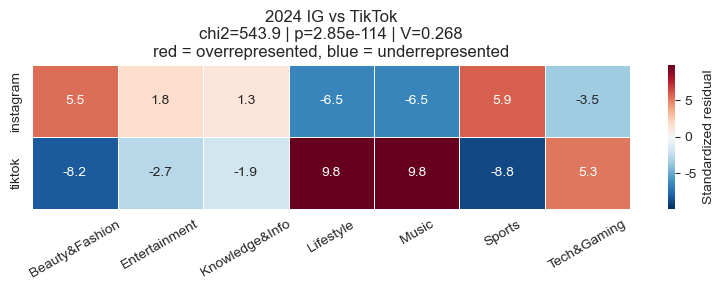

In [16]:
# ============================================================
# Step 4: Visualization 2 - Standardized residuals heatmap
# ============================================================

# Shared color scale across both panels for visual comparability
vmax = max(
    np.abs(res_22["std_residuals"].values).max(),
    np.abs(res_24["std_residuals"].values).max(),
)

# --- Figure 1: 2022 IG vs YouTube ---
fig1, ax1 = plt.subplots(figsize=(8, 3))
sns.heatmap(
    res_22["std_residuals"], annot=True, fmt=".1f",
    cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
    cbar_kws={"label": "Standardized residual"},
    ax=ax1, linewidths=0.5, linecolor="white",
)
ax1.set_title(
    f"2022 IG vs YouTube\nchi2={res_22['chi2']:.1f} | p={res_22['p']:.2e} | V={res_22['cramers_v']:.3f}\n"
    "red = overrepresented, blue = underrepresented"
)
ax1.set_xlabel("")
ax1.set_ylabel("")
ax1.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("rq2a_residuals_2022.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Figure 2: 2024 IG vs TikTok ---
fig2, ax2 = plt.subplots(figsize=(8, 3))
sns.heatmap(
    res_24["std_residuals"], annot=True, fmt=".1f",
    cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
    cbar_kws={"label": "Standardized residual"},
    ax=ax2, linewidths=0.5, linecolor="white",
)
ax2.set_title(
    f"2024 IG vs TikTok\nchi2={res_24['chi2']:.1f} | p={res_24['p']:.2e} | V={res_24['cramers_v']:.3f}\n"
    "red = overrepresented, blue = underrepresented"
)
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("rq2a_residuals_2024.png", dpi=150, bbox_inches="tight")
plt.show()


In [17]:
# ============================================================
# Step 5: Side-by-side summary + signature categories
# ============================================================

summary = pd.DataFrame({
    "Dataset": ["2022 IG vs YouTube", "2024 IG vs TikTok"],
    "n": [res_22["n"], res_24["n"]],
    "chi2": [f"{res_22['chi2']:.1f}", f"{res_24['chi2']:.1f}"],
    "df": [res_22["dof"], res_24["dof"]],
    "p-value": [f"{res_22['p']:.2e}", f"{res_24['p']:.2e}"],
    "Cramer's V": [f"{res_22['cramers_v']:.4f}", f"{res_24['cramers_v']:.4f}"],
    "Effect": [res_22["strength"], res_24["strength"]],
})

print("\n" + "=" * 70)
print("RQ2a Side-by-side comparison")
print("=" * 70)
print(summary.to_string(index=False))

# Signature categories per platform (|r| > 2 in standardized residuals)
print("\n\n=== Signature categories (|standardized residual| > 2) ===\n")

for label, res in [("2022 IG vs YouTube", res_22), ("2024 IG vs TikTok", res_24)]:
    sr = res["std_residuals"]
    print(f"--- {label} ---")
    for platform in sr.index:
        over = sr.loc[platform][sr.loc[platform] > 2].sort_values(ascending=False)
        under = sr.loc[platform][sr.loc[platform] < -2].sort_values()
        print(f"  {platform}:")
        if len(over) > 0:
            print(f"    Over-represented (signature): {dict(over.round(1))}")
        if len(under) > 0:
            print(f"    Under-represented:           {dict(under.round(1))}")
    print()


RQ2a Side-by-side comparison
           Dataset    n  chi2  df   p-value Cramer's V   Effect
2022 IG vs YouTube 2342 377.2   6  2.21e-78     0.4013 moderate
 2024 IG vs TikTok 7601 543.9   6 2.85e-114     0.2675     weak


=== Signature categories (|standardized residual| > 2) ===

--- 2022 IG vs YouTube ---
  instagram:
    Over-represented (signature): {'Sports': np.float64(6.6), 'Beauty&Fashion': np.float64(4.9), 'Lifestyle': np.float64(2.9)}
    Under-represented:           {'Tech&Gaming': np.float64(-6.4), 'Knowledge&Info': np.float64(-5.9), 'Music': np.float64(-2.6)}
  youtube:
    Over-represented (signature): {'Tech&Gaming': np.float64(7.5), 'Knowledge&Info': np.float64(7.0), 'Music': np.float64(3.0)}
    Under-represented:           {'Sports': np.float64(-7.7), 'Beauty&Fashion': np.float64(-5.7), 'Lifestyle': np.float64(-3.5)}

--- 2024 IG vs TikTok ---
  instagram:
    Over-represented (signature): {'Sports': np.float64(5.9), 'Beauty&Fashion': np.float64(5.5)}
    Under-repr